In [57]:
!pip install "numpy<2"
!pip show numpy | !head -10

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
zsh:1: command not found: !head
ERROR: Pipe to stdout was broken
Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


In [81]:
import numpy as np
import os
import pytorch_lightning as pl
import torch
import webdataset as wds
from torchvision.transforms import transforms
from torchvision.transforms.functional import to_tensor

from configs.utils import instantiate_from_config

class AddEqual_fp16_DogPose(object):  # 创建一个新类

    def __init__(self):
        print('Process function for DogPose: jpg and pose.jpg')

    def __call__(self, sample):
        print(sample.keys())
        if 'jpg' in sample:
            sample['jpg'] = to_tensor(sample['jpg'])
            
        if 'pose_jpg' in sample:
            sample['pose'] = to_tensor(sample['pose_jpg'])
            
            del sample['pose_jpg']

        return sample

def dict_collation_fn(samples, combine_tensors=True, combine_scalars=True):
    """Take a list  of samples (as dictionary) and create a batch, preserving the keys.
    If `tensors` is True, `ndarray` objects are combined into
    tensor batches.
    :param dict samples: list of samples
    :param bool tensors: whether to turn lists of ndarrays into a single ndarray
    :returns: single sample consisting of a batch
    :rtype: dict
    """
    keys = set.intersection(*[set(sample.keys()) for sample in samples])
    batched = {key: [] for key in keys}

    for s in samples:
        [batched[key].append(s[key]) for key in batched]

    result = {}
    for key in batched:
        if isinstance(batched[key][0], (int, float)):
            if combine_scalars:
                result[key] = np.array(list(batched[key]))
        elif isinstance(batched[key][0], torch.Tensor):
            if combine_tensors:
                result[key] = torch.stack(list(batched[key]))
        elif isinstance(batched[key][0], np.ndarray):
            if combine_tensors:
                result[key] = np.array(list(batched[key]))
        else:
            result[key] = list(batched[key])
    return result

class WebDataModuleFromConfig_DogPose:

    # 构造函数可以简化，因为我们不再需要两个数据源
    def __init__(self,
                 tar_base,  # 只需要一个 tar_base
                 batch_size,
                 train=None,
                 validation=None,
                 num_workers=4,
                 multinode=True,
                 **kwargs):
        super().__init__()
        print(f'Setting tar base to {tar_base}')
        self.tar_base = tar_base
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train = train
        self.validation = validation
        self.multinode = multinode
        self.dataloader = self.make_loader()

    def make_loader(self):
        # image_transforms 保持不变 (用于 .jpg)
        image_transforms = [transforms.Resize(size=1024, interpolation=3),
                            transforms.RandomCrop(size=1024)]
        image_transforms = transforms.Compose(image_transforms)

        # process 函数将同时处理 .jpg 和 .pose.jpg
        # 我们假设 process 函数 (如 AddEqual_fp16) 只是将 PIL 转为 Tensor
        # 它将被 map_dict 用到两个键上
        process = AddEqual_fp16_DogPose()

        shuffle = 10000
        shardshuffle = shuffle > 0
        nodesplitter = wds.shardlists.split_by_node if self.multinode else wds.shardlists.single_node_only

        tars = os.path.join(self.tar_base, 'dogpose-shard-{000000..000006}.tar')

        dset = wds.WebDataset(
            tars, nodesplitter=nodesplitter, shardshuffle=shardshuffle,
            handler=wds.warn_and_continue).repeat().shuffle(shuffle)
        print(f'Loading webdataset with {len(dset.pipeline[0].urls)} shards.')

        dset = (
            dset.select(self.filter_keys)  # <-- 修改 filter_keys
            .decode('pil', handler=wds.warn_and_continue)
            .rename(pose_jpg="pose.jpg", handler=wds.warn_and_continue)
            .map_dict(
                jpg=image_transforms,  # 对原始图应用变换 (如裁剪)
                pose_jpg=image_transforms,  # 对条件图应用同样的变换，确保对齐！
                handler=wds.warn_and_continue
            )
        )
        dset = (dset.batched(self.batch_size, partial=False, collation_fn=dict_collation_fn))

        loader = wds.WebLoader(dset, batch_size=None, shuffle=False, num_workers=self.num_workers)
        return loader

    def filter_keys(self, x):
        try:
            # **[重要修改]** 检查所有需要的键
            return ("jpg" in x) and ("txt" in x) and ("pose.jpg" in x) and ("json" in x)
        except Exception:
            return False

In [82]:
def test_dataloader():
    data = WebDataModuleFromConfig_DogPose(tar_base="data/Dogpose_wiPose_train",
                                           batch_size=2,
                                           num_workers=0,
                                           )
    train_dataloader = data.dataloader
    for step, batch in enumerate(train_dataloader):
        return batch

Setting tar base to data/Dogpose_wiPose_train
Process function for DogPose: jpg and pose.jpg
Loading webdataset with 7 shards.


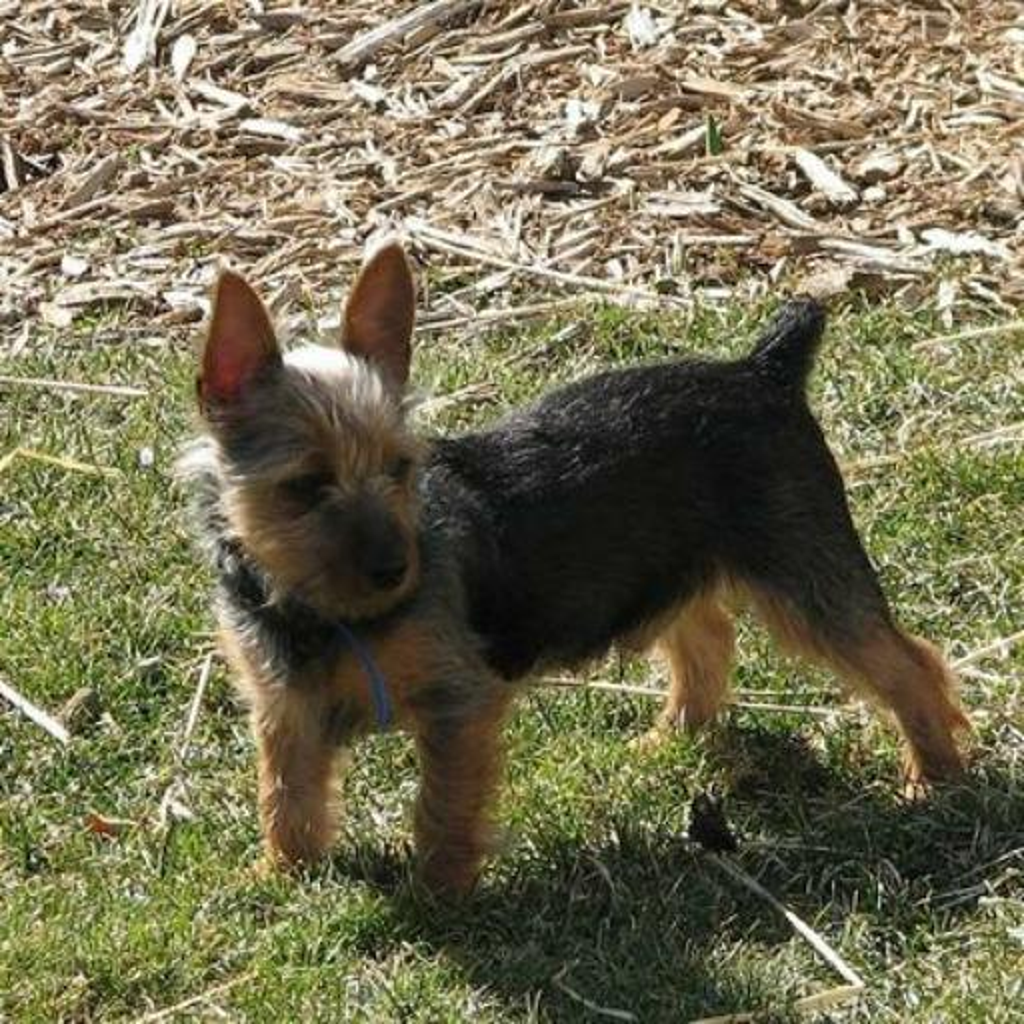

In [100]:
test_data = test_dataloader()
test_data['jpg'][1]

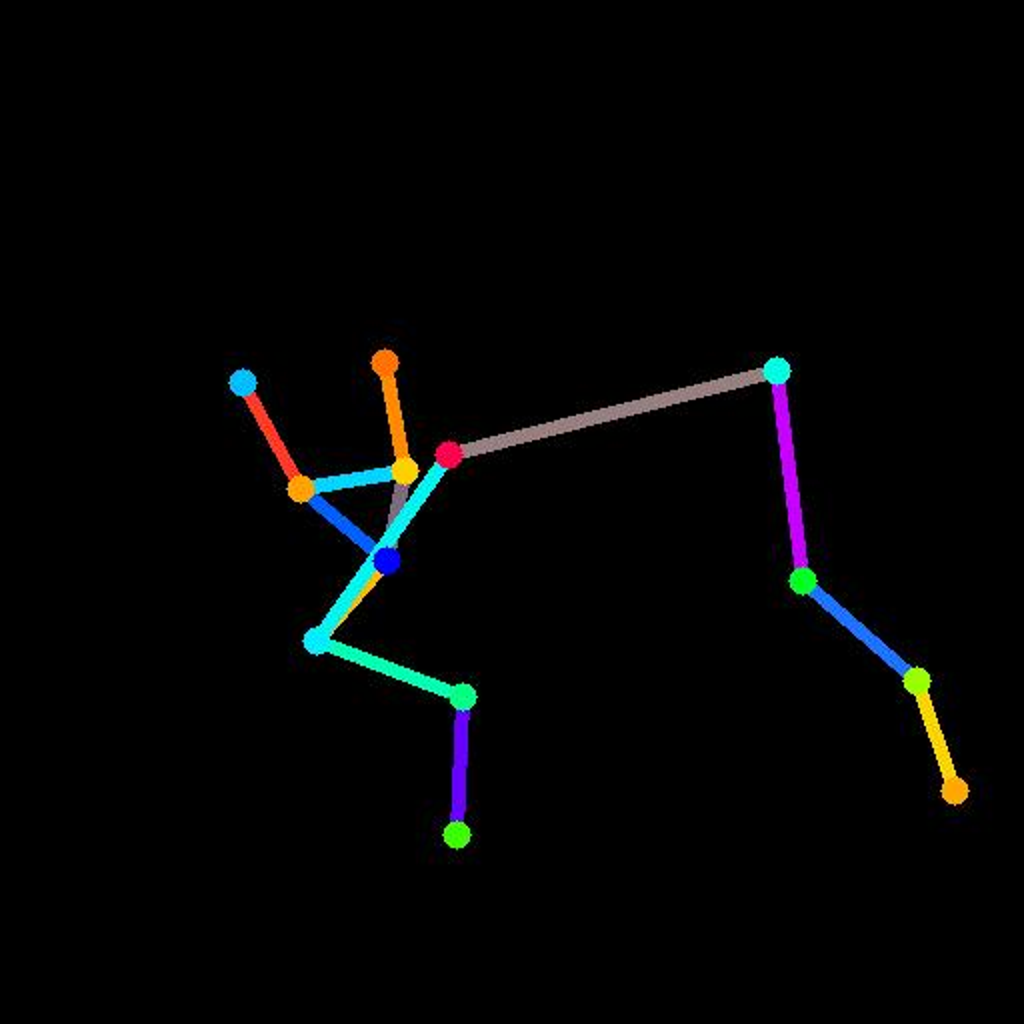

In [101]:
test_data['pose_jpg'][1]